Загружаем данные и удаляем ненужный столбец.

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv('bikes_rent.csv', decimal=',')
df = df.drop(columns=["Unnamed: 13"])
df = df.dropna()

Зависимость целевого признака от других на графиках.

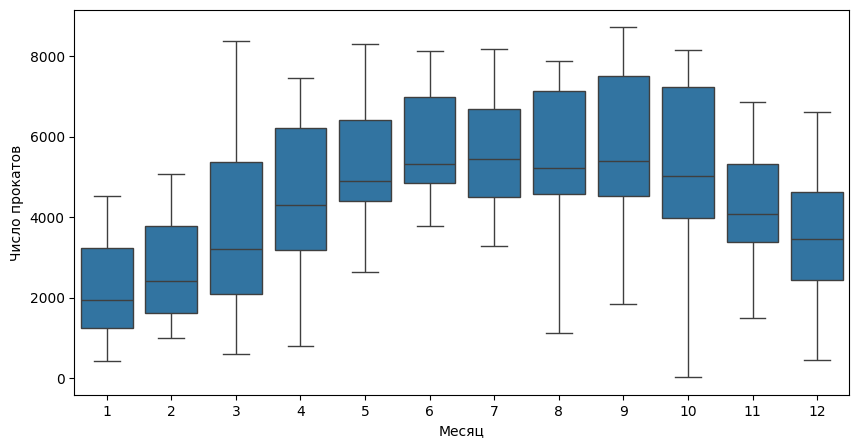

In [61]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='mnth', y='cnt', data=df)
plt.xlabel('Месяц')
plt.ylabel('Число прокатов')
plt.show()

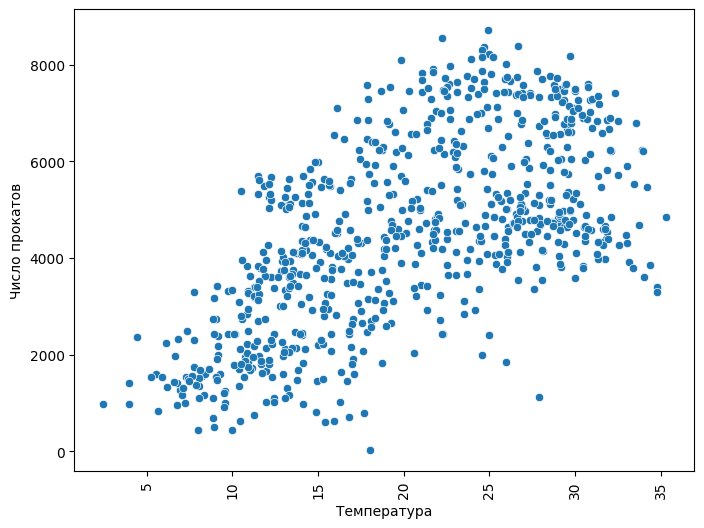

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='temp', y='cnt', data=df)
plt.xlabel('Температура')
plt.ylabel('Число прокатов')
plt.xticks(rotation=90)
plt.show()

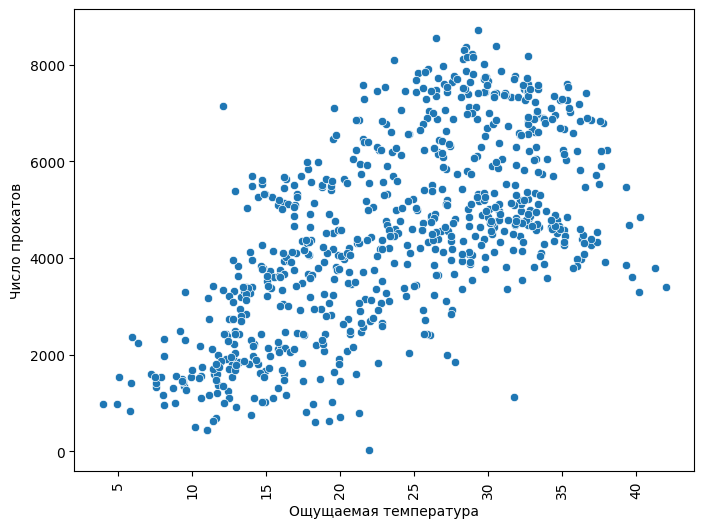

In [63]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='atemp', y='cnt', data=df)
plt.xlabel('Ощущаемая температура')
plt.ylabel('Число прокатов')
plt.xticks(rotation=90)
plt.show()


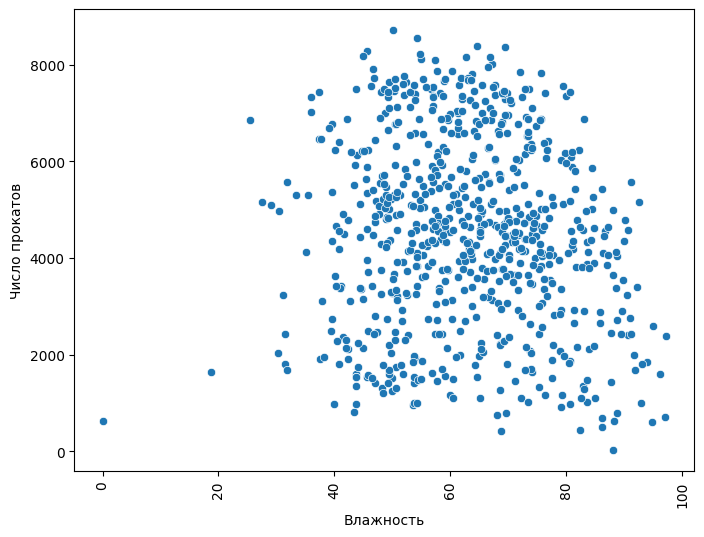

In [64]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='hum', y='cnt', data=df)
plt.xlabel('Влажность')
plt.ylabel('Число прокатов')
plt.xticks(rotation=90)
plt.show()

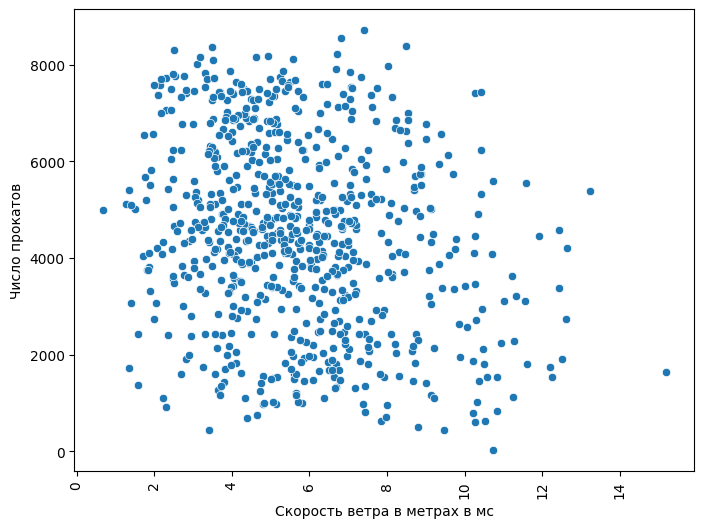

In [65]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='windspeed(ms)', y='cnt', data=df)
plt.xlabel('Скорость ветра в метрах в мс')
plt.ylabel('Число прокатов')
plt.xticks(rotation=90)
plt.show()

У температуры есть наиболее чёткий график по которому можно увидеть корреляцию.

2. Есть ли в данных похожие или дублирующие друг друга признаки? Как вы можете показать их похожесть? Удалите такие признаки из датасета.

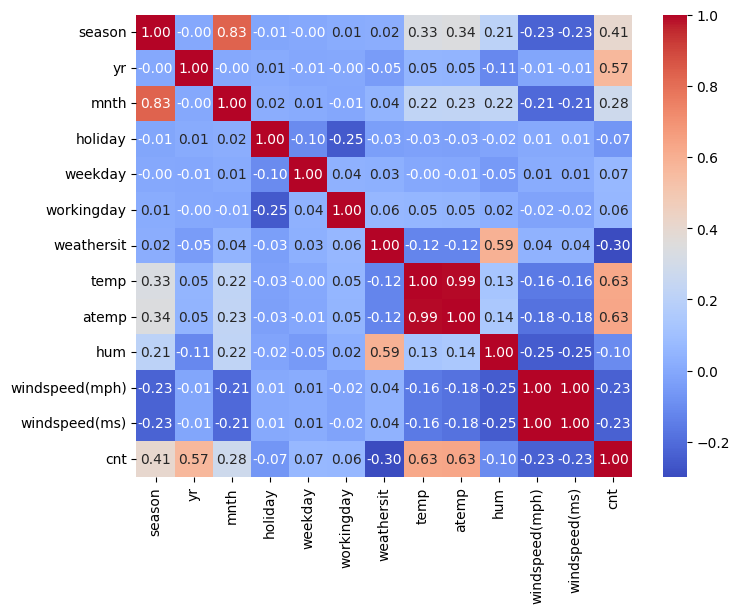

In [66]:
corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

Видим абсолютную зависимость по признакам которые означают одно и тоже(почти одно и тоже в виде чувствительной температуры).

In [67]:
df = df.drop(columns=['atemp', 'windspeed(mph)'])


3. Разбейте данные на тренировочные и тестовые. Обучите модель линейной регрессии. Выведите точность предсказания модели для тестовых данных.

In [68]:
X = df.drop(columns=['cnt'])
y = df['cnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Обучаем модель и смотрим результаты.

In [69]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = r2_score(y_test, y_pred)

print(accuracy)

0.827044785046549
